# Analysis of parking occupancy
Compared to archive: Take base occupancy as parking supply and analyse the relative overshoot during the policy case.

In [53]:
import pandas as pd
%config InlineBackend.figure_format = 'retina'

base_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended-10pct/"
base_parking = pd.read_csv(base_path + "parking_occupancy.csv.zst")

policy_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-policy-10pct_walkPlanFix"
policy_parking = pd.read_csv("%s/ITERS/it.500/berlin-v6.4.500.parking_occupancy.csv.zst" % policy_path)

pct = 0.1

In [54]:
import geopandas as gpd

df_links = pd.read_csv(
    base_path + "berlin-v6.4.output_links.csv.zst",
    sep=";",
    compression="zstd",
    dtype={"link": "string"},
    low_memory=False,
)

links = gpd.GeoDataFrame(
    df_links[~df_links["link"].str.contains("pt_")],
    geometry=gpd.GeoSeries.from_wkt(df_links["geometry"], crs="EPSG:25832"),
)
links

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,vol_truck,allowed_speed,maxInflowUsedInQsim,name,speed_factor,restricted_lanes,hbefa_road_type,storageCapacityUsedInQsim,type,geometry
0,-1000055665,6773970060,267855868,28.01,4.634,634.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",2,0,...,1,13.89,1053.102038,Lindenweg,4.634,NaN,URB/Access/50,NaN,highway.residential,"LINESTRING (796573.1 5797464.9, 796580.93 5797..."
1,-1000098209,29266788,29266795,58.56,2.554,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",13,0,...,0,2.78,760.043646,Lilli-Henoch-Straße,2.554,NaN,URB/Access/30,0.821848,highway.living_street,"LINESTRING (800578.77 5830375.13, 800629.32 58..."
2,-100012092,2288369966,1017979482,223.51,9.344,1896.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,1,...,0,13.89,1383.203395,Dorfstraße,9.344,NaN,URB/Local/50,4.084962,highway.tertiary,"LINESTRING (807040 5714450.85, 806856.97 57145..."
3,-1000121005,9231911647,3869622346,136.97,10.460,1933.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",148,26,...,11,13.89,1430.264357,Lichtenrader Straße,10.460,NaN,URB/Access/50,2.468196,highway.unclassified,"LINESTRING (799342.3 5811143.42, 799386.89 581..."
4,-1000268036,94673071,7829689846,69.88,7.133,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",32,4,...,2,8.33,1262.515118,Roseggerstraße,7.133,NaN,URB/Access/30,NaN,highway.residential,"LINESTRING (802003.09 5823888.17, 801962.85 58..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213956,999753858,cluster_10219572135_247947537_4796865042_80644...,8310059767,21.17,3.231,1666.0,1.0,bike,0,0,...,0,5.56,873.518677,NaN,3.231,NaN,URB/Access/30,0.538347,highway.cycleway,"LINESTRING (809649.3 5829245.86, 809633.22 582..."
213957,999943085,9135760767,cluster_9193459685_95920977,165.26,5.561,1412.0,1.0,bike,0,0,...,0,5.56,1143.336874,NaN,5.561,NaN,URB/Access/30,2.721241,highway.path,"LINESTRING (813176.2 5831254, 813018.57 583120..."
213958,999943090#1,cluster_9193459685_95920977,cluster_9196165417_95920978,147.05,5.625,1412.0,1.0,bike,0,0,...,0,5.56,1148.936170,NaN,5.625,NaN,URB/Access/30,2.409587,highway.path,"LINESTRING (813018.57 5831208.39, 812877.65 58..."
213959,999948146#1,258956777,268072032,175.76,7.158,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",33,3,...,3,8.33,1264.143168,Goethestraße,7.158,NaN,URB/Access/30,NaN,highway.residential,"LINESTRING (801940.36 5803217.47, 802026.89 58..."


In [55]:
bezirke = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/bezirksgrenzen.geojson")
bezirke = bezirke.to_crs(epsg=3857)

## Parking Cost

In [56]:
# join base and policy on linkId.
merged = base_parking.merge(policy_parking, on="linkId", suffixes=("_base", "_policy"))
merged["occupancy_diff"] = merged["occupancy_policy"] - merged["occupancy_base"]
merged["relative_overshoot"] = merged["occupancy_diff"] / merged["occupancy_base"].replace(0,pd.NA)  # avoid division by zero, set to NA
merged

,linkId,from_time_base,to_time_base,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
0,15805101#0,0.0,561.0,91.18,16.0,16.0,0.0,561.0,91.18,16.0,16.0,0.0,0.000000
1,1117976084,39815.0,40302.0,144.20,7.0,3.0,39066.0,39113.0,144.20,7.0,3.0,0.0,0.000000
2,-24686377,33447.0,45700.0,104.73,1.0,0.0,33577.0,43552.0,104.73,1.0,0.0,0.0,0.000000
3,-128840035,28932.0,33604.0,911.86,2.0,0.0,28932.0,33058.0,911.86,2.0,0.0,0.0,0.000000
4,-437656682#2,0.0,36864.0,45.37,1.0,1.0,0.0,30834.0,45.37,1.0,1.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62188,-24214516,45310.0,45334.0,287.63,37.0,31.0,44984.0,45173.0,287.63,35.0,31.0,-2.0,-0.054054
62189,-25814594#1,50260.0,51974.0,44.92,1.0,0.0,50195.0,51909.0,44.92,1.0,0.0,0.0,0.000000
62190,-25814594#0,38080.0,39190.0,190.92,6.0,2.0,37999.0,38082.0,190.92,6.0,2.0,0.0,0.000000
62191,-1125022715,33837.0,35593.0,442.76,2.0,0.0,33813.0,35451.0,442.76,2.0,0.0,0.0,0.000000


In [57]:
# join merged with links on linkId and link, keep all columns
final = links.merge(merged, left_on="link", right_on="linkId", how="left")
final_3857 = final.to_crs(epsg=3857)
final_3857["geometry"] = final_3857.geometry.simplify(2)
# final_3857["relative_overshoot"] = final_3857["relative_overshoot"]
# final_3857[final_3857["link"] == "306046325"]
final_3857

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
0,-1000055665,6773970060,267855868,28.01,4.634,634.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",2,0,...,28.01,1.0,0.0,58292.0,65946.0,28.01,1.0,0.0,0.0,0.0
1,-1000098209,29266788,29266795,58.56,2.554,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",13,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-100012092,2288369966,1017979482,223.51,9.344,1896.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,1,...,223.51,1.0,1.0,0.0,19297.0,223.51,1.0,1.0,0.0,0.0
3,-1000121005,9231911647,3869622346,136.97,10.460,1933.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",148,26,...,136.97,1.0,0.0,53873.0,55634.0,136.97,1.0,0.0,0.0,0.0
4,-1000268036,94673071,7829689846,69.88,7.133,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",32,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213956,999753858,cluster_10219572135_247947537_4796865042_80644...,8310059767,21.17,3.231,1666.0,1.0,bike,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213957,999943085,9135760767,cluster_9193459685_95920977,165.26,5.561,1412.0,1.0,bike,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213958,999943090#1,cluster_9193459685_95920977,cluster_9196165417_95920978,147.05,5.625,1412.0,1.0,bike,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213959,999948146#1,258956777,268072032,175.76,7.158,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",33,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Number of links with relative overshoot > 4: 94
Percentiles of relative_overshoot:
0.250    0.000000
0.500    0.000000
0.750    0.000000
0.900    0.000000
0.950    0.142857
0.990    1.000000
0.999    6.000000
Name: relative_overshoot, dtype: float64


<Axes: ylabel='Frequency'>

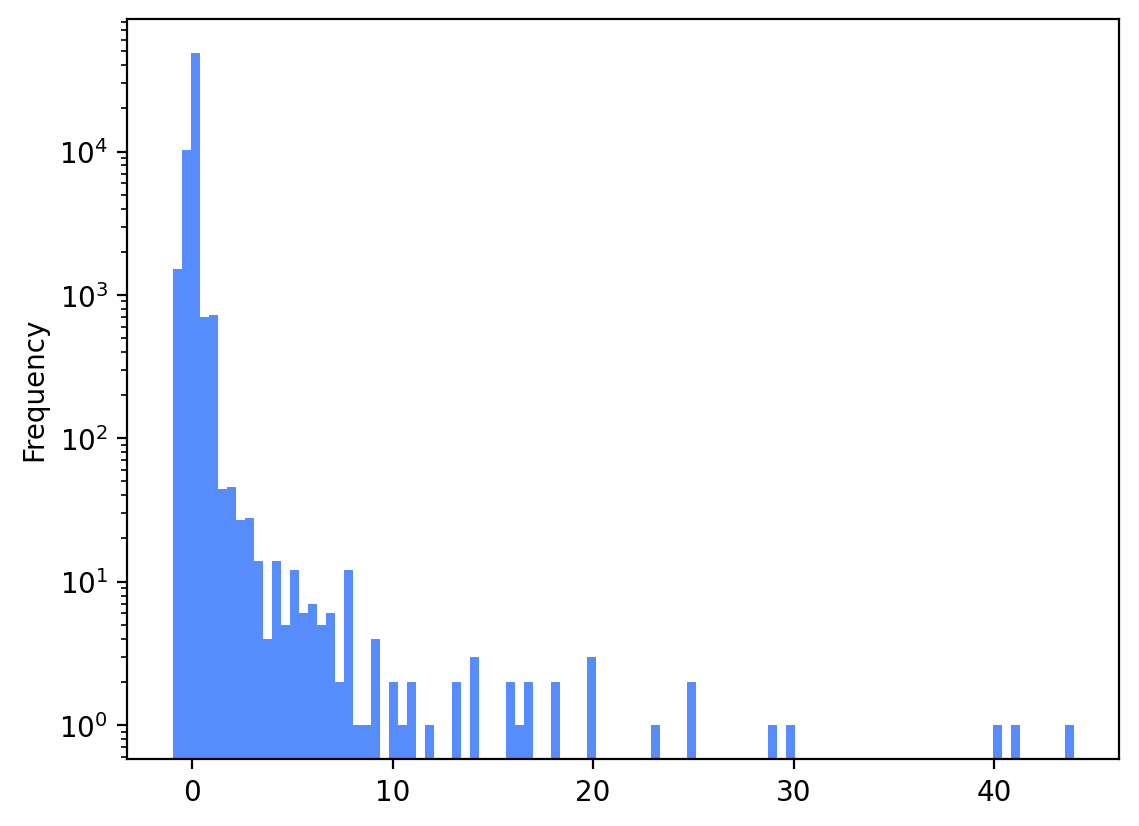

In [58]:
# count how many links have a relative_overshoot of >4
num_links_overshoot = (final_3857["relative_overshoot"] > 4).sum()
print(f"Number of links with relative overshoot > 4: {num_links_overshoot}")

# print percentiles of relative_overshoot
percentiles = final_3857["relative_overshoot"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print("Percentiles of relative_overshoot:")
print(percentiles)

# make a hist plot of relative_overshoot, excluding NA values and log y axis
final_3857["relative_overshoot"].dropna().plot.hist(bins=100, log=True)

<Axes: ylabel='Frequency'>

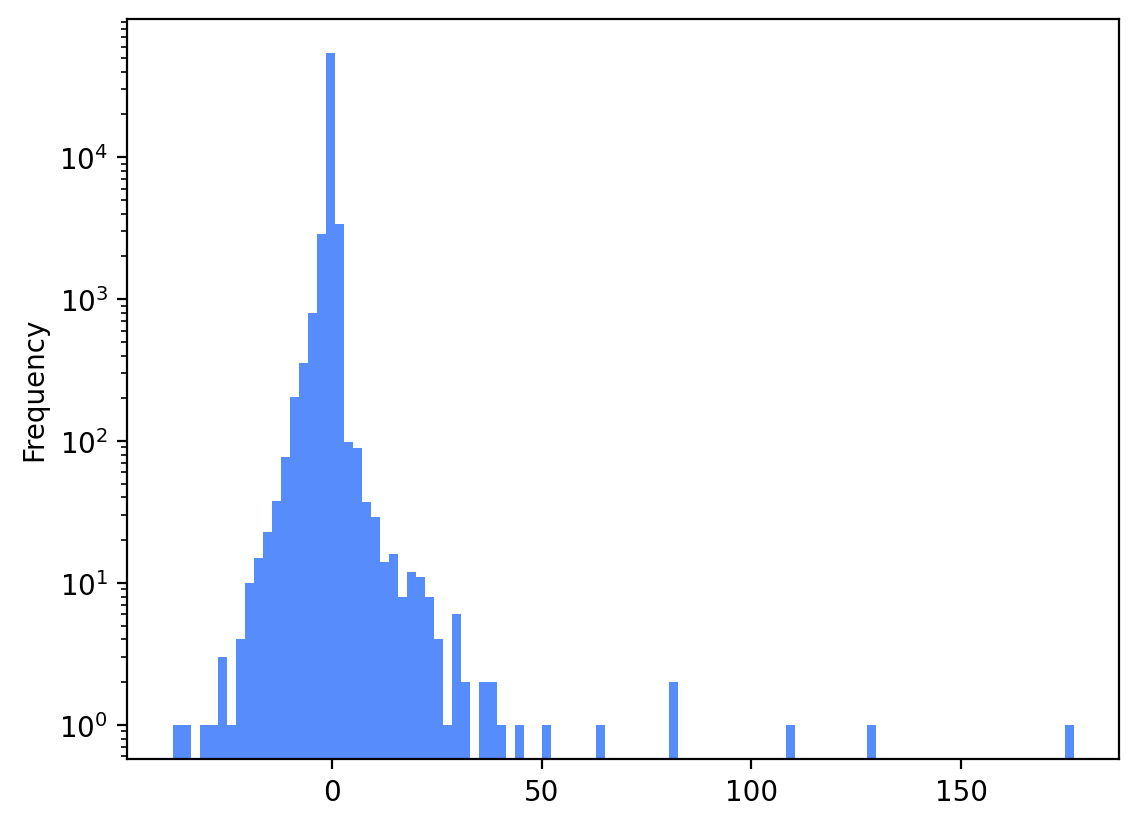

In [59]:
final_3857["occupancy_diff"].dropna().plot.hist(bins=100, log=True)

<Axes: xlabel='relative_overshoot', ylabel='occupancy_diff'>

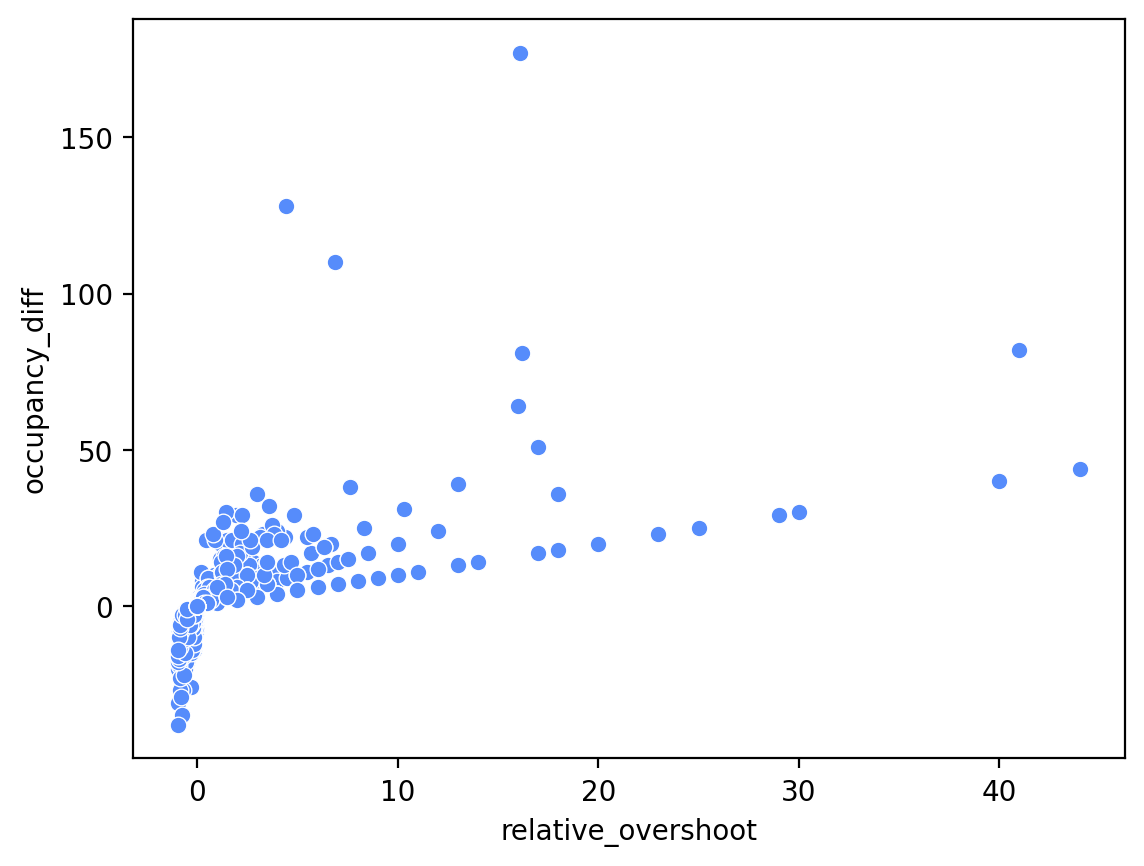

In [60]:
import seaborn as sns
sns.scatterplot(final_3857, x="relative_overshoot", y="occupancy_diff")

In [61]:
value_col = "relative_overshoot"

final_3857[value_col] = pd.to_numeric(final_3857[value_col], errors="coerce")
gdf_plot = final_3857.loc[
    final_3857[value_col].notna() & (final_3857[value_col] > 0) #& (final_3857[value_col] > 1.0)
].copy()

# print row count of gdf_plot
zone = gpd.read_file('../../../../input/v6.4/umweltzone/Umweltzone_Berlin.shp')

# gdf_plot[gdf_plot.geometry.within(zone.to_crs(epsg=3857).union_all())].shape[1]
# filtered = gdf_plot[gdf_plot.geometry.within(zone.to_crs(epsg=3857).union_all())]
filtered = gdf_plot
filtered

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
39,-1001610610#0,8932206323,7511576880,108.09,6.760,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",2,5,...,108.09,1.0,1.0,59890.0,62444.0,108.09,2.0,1.0,1.0,1.000000
60,-1002247009,8926454464,2813721969,34.10,8.578,3380.0,2.0,"bike,car,commercial_goods_car,freight,ride,truck",250,523,...,34.10,1.0,0.0,70689.0,70692.0,34.10,45.0,38.0,44.0,44.000000
244,-10081221,82896082,82896078,132.44,6.503,1139.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",16,1,...,132.44,10.0,2.0,44009.0,44859.0,132.44,11.0,2.0,1.0,0.100000
329,-1009306053#0,1509404630,3729849874,18.86,9.357,1969.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",440,494,...,18.86,1.0,1.0,43456.0,50166.0,18.86,2.0,1.0,1.0,1.000000
342,-1009876363,61083396,61083395,363.34,10.366,1139.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",58,49,...,363.34,6.0,1.0,45295.0,45780.0,363.34,7.0,1.0,1.0,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213024,9858759#0,4934304001,4934304000,84.26,5.062,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",12,0,...,84.26,6.0,5.0,69954.0,70428.0,84.26,7.0,5.0,1.0,0.166667
213043,986163882#1,340279500,cluster_21487273_27539580,69.41,8.751,4108.0,2.0,"bike,car,commercial_goods_car,freight,ride,truck",1117,1283,...,69.41,2.0,1.0,66359.0,66699.0,69.41,5.0,2.0,3.0,1.500000
213190,9888058,79838917,79838953,78.28,8.112,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",83,1,...,78.28,11.0,0.0,62965.0,63032.0,78.28,14.0,0.0,3.0,0.272727
213493,992291614,47955423,47955517,785.16,27.868,4130.0,2.0,"car,commercial_goods_car,freight,ride,truck",1332,1129,...,785.16,3.0,0.0,70189.0,70316.0,785.16,4.0,0.0,1.0,0.333333


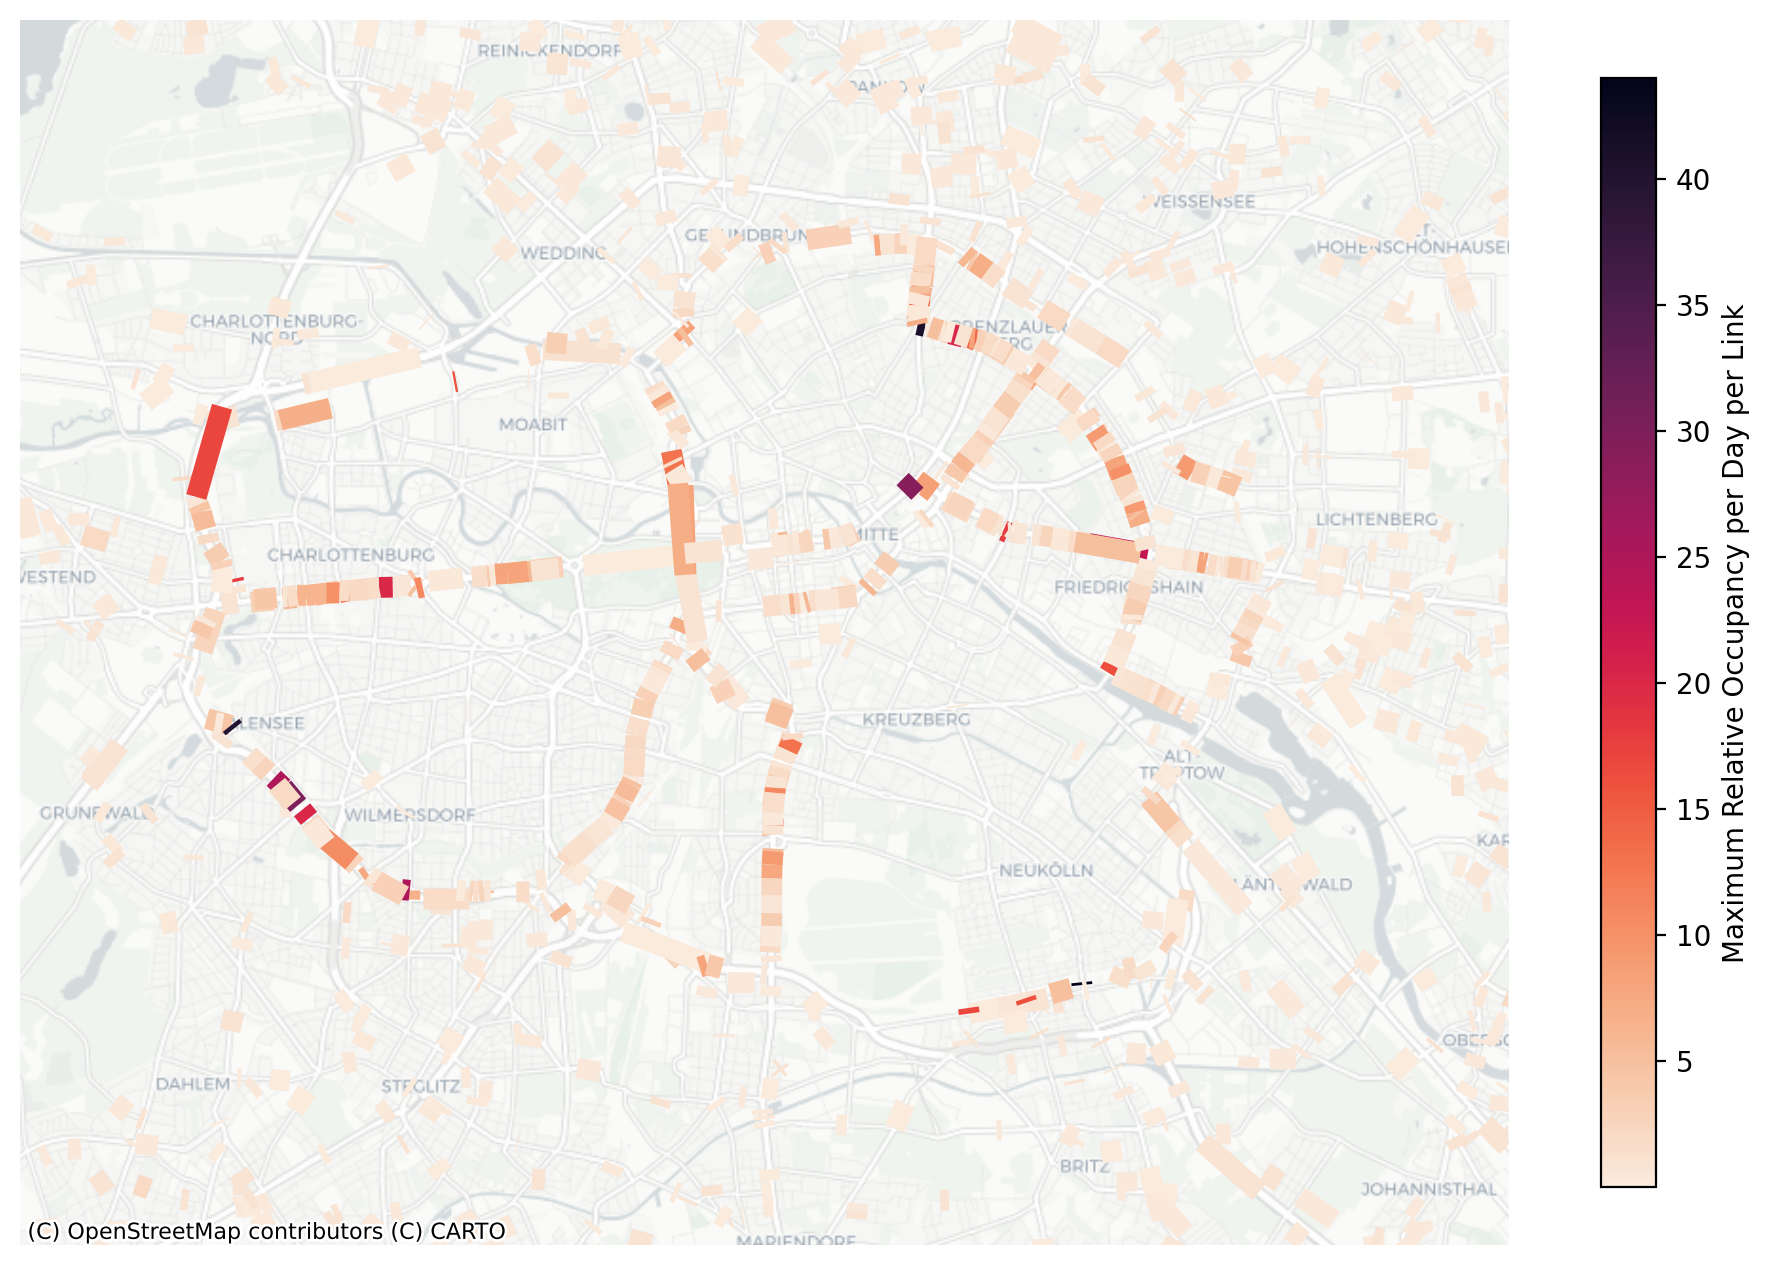

In [62]:

import contextily as ctx
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

# vmin = gdf_plot[value_col].min()
# vmax = gdf_plot[value_col].max()
#
# cmap = plt.cm.viridis
# norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

gdf_plot.plot(
    column=value_col,
    ax=ax,
    cmap="rocket_r",
    linewidth=7.5,
    # cmap=cmap,
    # norm=norm,
    legend=True,  # <- important: turn off geopandas legend
    # edgecolor="none",
    legend_kwds={
        "label": "Maximum Relative Occupancy per Day per Link",
        "shrink": 0.6,      # scale height of colorbar
        # "aspect": 20,       # thickness ratio
        # "pad": 0.01,        # spacing to plot
        # "fraction": 0.03,   # width relative to plot
    }
)
#
# sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])  # needed for older mpl behavior
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label("Relative Overshoot")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
ax.set_axis_off()

minx, miny, maxx, maxy = bezirke.total_bounds

x_diff = maxx - minx
y_diff = maxy - miny
buffer_factor = -0.3
minx -= x_diff * buffer_factor * 0.8
maxx += x_diff * buffer_factor * 1.2
miny -= y_diff * buffer_factor
maxy += y_diff * buffer_factor

ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])

title = "max-daily-occupancy"
plt.savefig("./plots/" + title + ".pdf", dpi=300, bbox_inches="tight", pad_inches=0)

plt.show()


## Parking Cost per Time Step

In [37]:
policy_parking_cost = pd.read_csv(policy_path + "/ITERS/it.500/berlin-v6.4.500.parking_costs.csv.zst")

cost_df = links.merge(policy_parking_cost, left_on="link", right_on="linkId", how="left")
# set all cost_df[cost] = NaN values to 0
cost_df["cost"] = cost_df["cost"].fillna(0)

cost_df = cost_df.to_crs(epsg=3857)
cost_df["geometry"] = cost_df.geometry.simplify(2)

In [38]:
# filtered_cost = cost_df[cost_df["cost"] > 0.1]
# filtered_cost = filtered_cost[filtered_cost["from_time"] == 14 * 3600]

# group cost_df by link and take largest value in cost col 
filtered_cost = (
    cost_df.sort_values("cost", ascending=False)
    .drop_duplicates("link", keep="first")
)
filtered_cost = filtered_cost[filtered_cost["cost"] > 0.2]


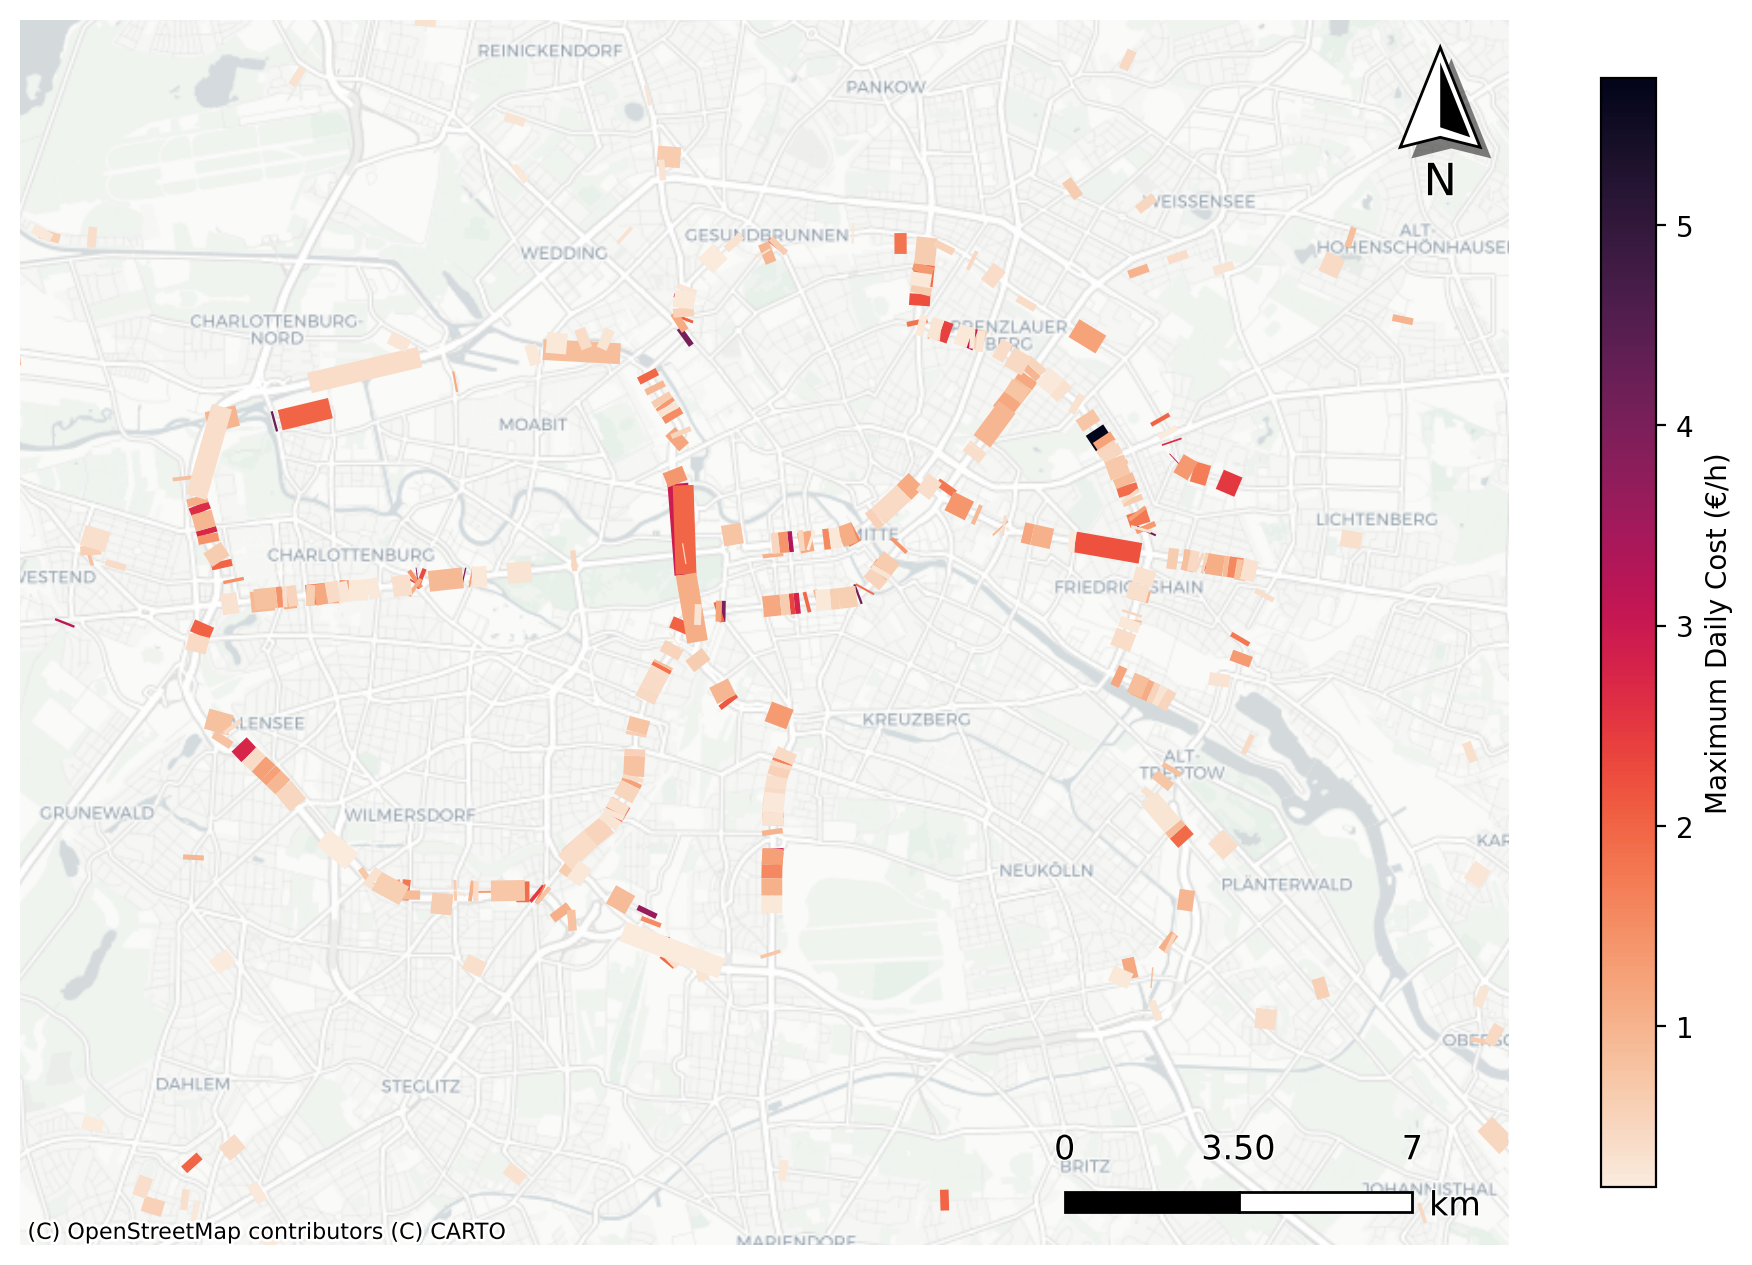

In [39]:
import contextily as ctx
import matplotlib.pyplot as plt

from matplotlib_map_utils.core.north_arrow import north_arrow
from matplotlib_map_utils.core.scale_bar import scale_bar

fig, ax = plt.subplots(figsize=(12, 12))

value_col = "cost"

filtered_cost.plot(
    column=value_col,
    ax=ax,
    cmap="rocket_r",
    # norm=norm,
    legend=True,  # <- important: turn off geopandas legend
    # edgecolor="none",
    linewidth=7.5,
    legend_kwds={
        "label": "Maximum Daily Cost (€/h)",
        "shrink": 0.6,      # scale height of colorbar
        # "aspect": 20,       # thickness ratio
        # "pad": 0.01,        # spacing to plot
        # "fraction": 0.03,   # width relative to plot
    }
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
ax.set_axis_off()

north_arrow(
    ax, location="upper right", rotation={"crs": filtered_cost.crs, "reference": "center"}
)
scale_bar(ax, location="lower right", style="boxes", bar={"projection": filtered_cost.crs, "unit": "km"})

minx, miny, maxx, maxy = bezirke.total_bounds

x_diff = maxx - minx
y_diff = maxy - miny
buffer_factor = -0.3
minx -= x_diff * buffer_factor * 0.8
maxx += x_diff * buffer_factor * 1.2
miny -= y_diff * buffer_factor
maxy += y_diff * buffer_factor

ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])

title = "max-daily-cost"
plt.savefig("./plots/" + title + ".pdf", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()


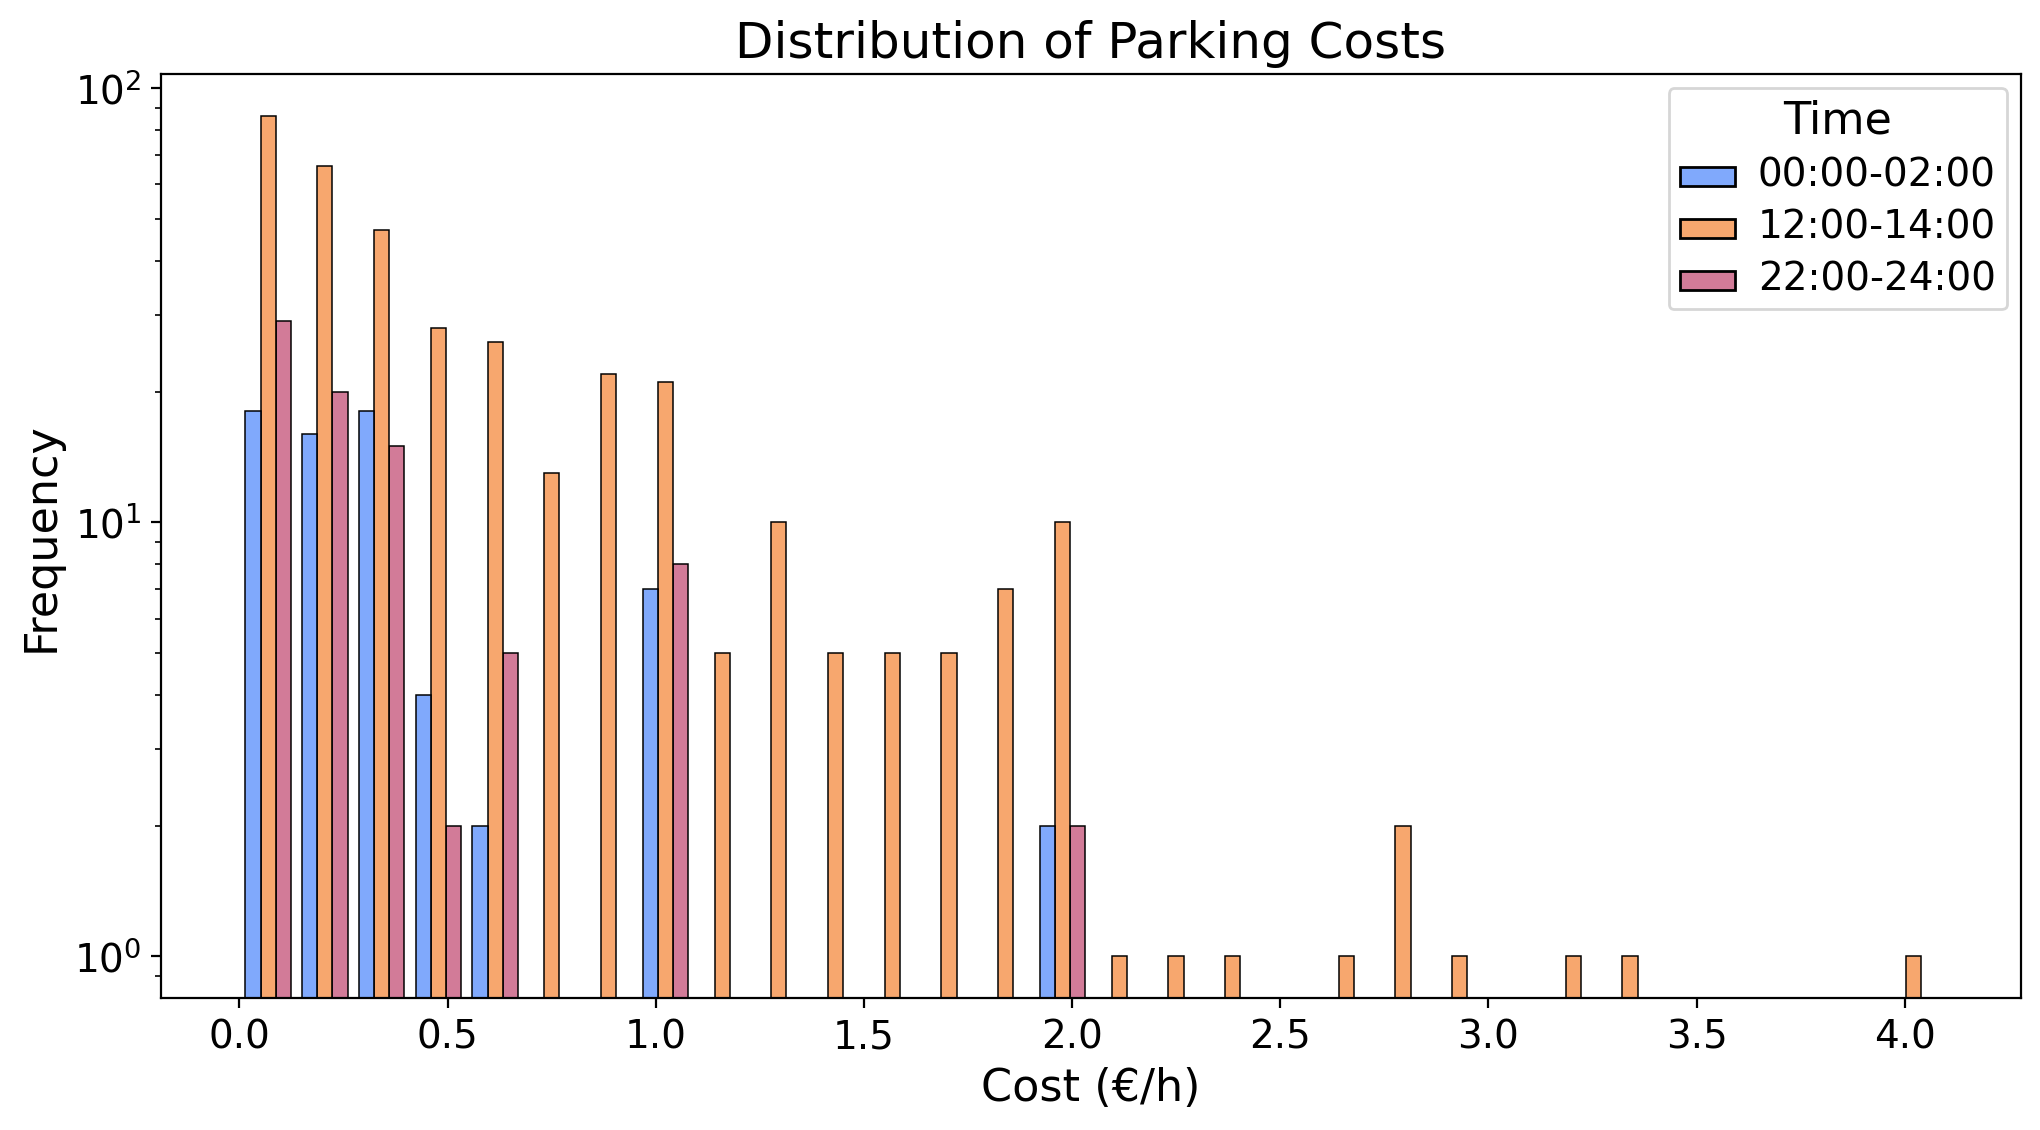

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = cost_df[cost_df["from_time"].isin([0, 12*3600, 22*3600])]
df = df[df["cost"] > 0.0]

mapping = {
    0: "00:00-02:00",
    12*3600: "12:00-14:00",
    22*3600: "22:00-24:00",
}

order = ["00:00-02:00", "12:00-14:00", "22:00-24:00"]

df["time_label"] = df["from_time"].map(mapping)
df["time_label"] = pd.Categorical(
    df["time_label"],
    categories=order,
    ordered=True,
)

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=df,
    x="cost",
    hue="time_label",
    bins=30,
    multiple="dodge",
    shrink=0.8,
    common_bins=True,
)

plt.yscale("log")

# Axis labels
plt.xlabel("Cost (€/h)", fontsize=16)
plt.ylabel("Frequency", fontsize=16)

# Title
title = "Distribution of Parking Costs"
plt.title(title, fontsize=18)

# Tick label sizes
ax.tick_params(axis='both', labelsize=14)

# Legend formatting
legend = ax.get_legend()
legend.set_title("Time", prop={"size": 16})

for text in legend.get_texts():
    text.set_fontsize(14)


plt.savefig(
    "./plots/" + title + ".pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

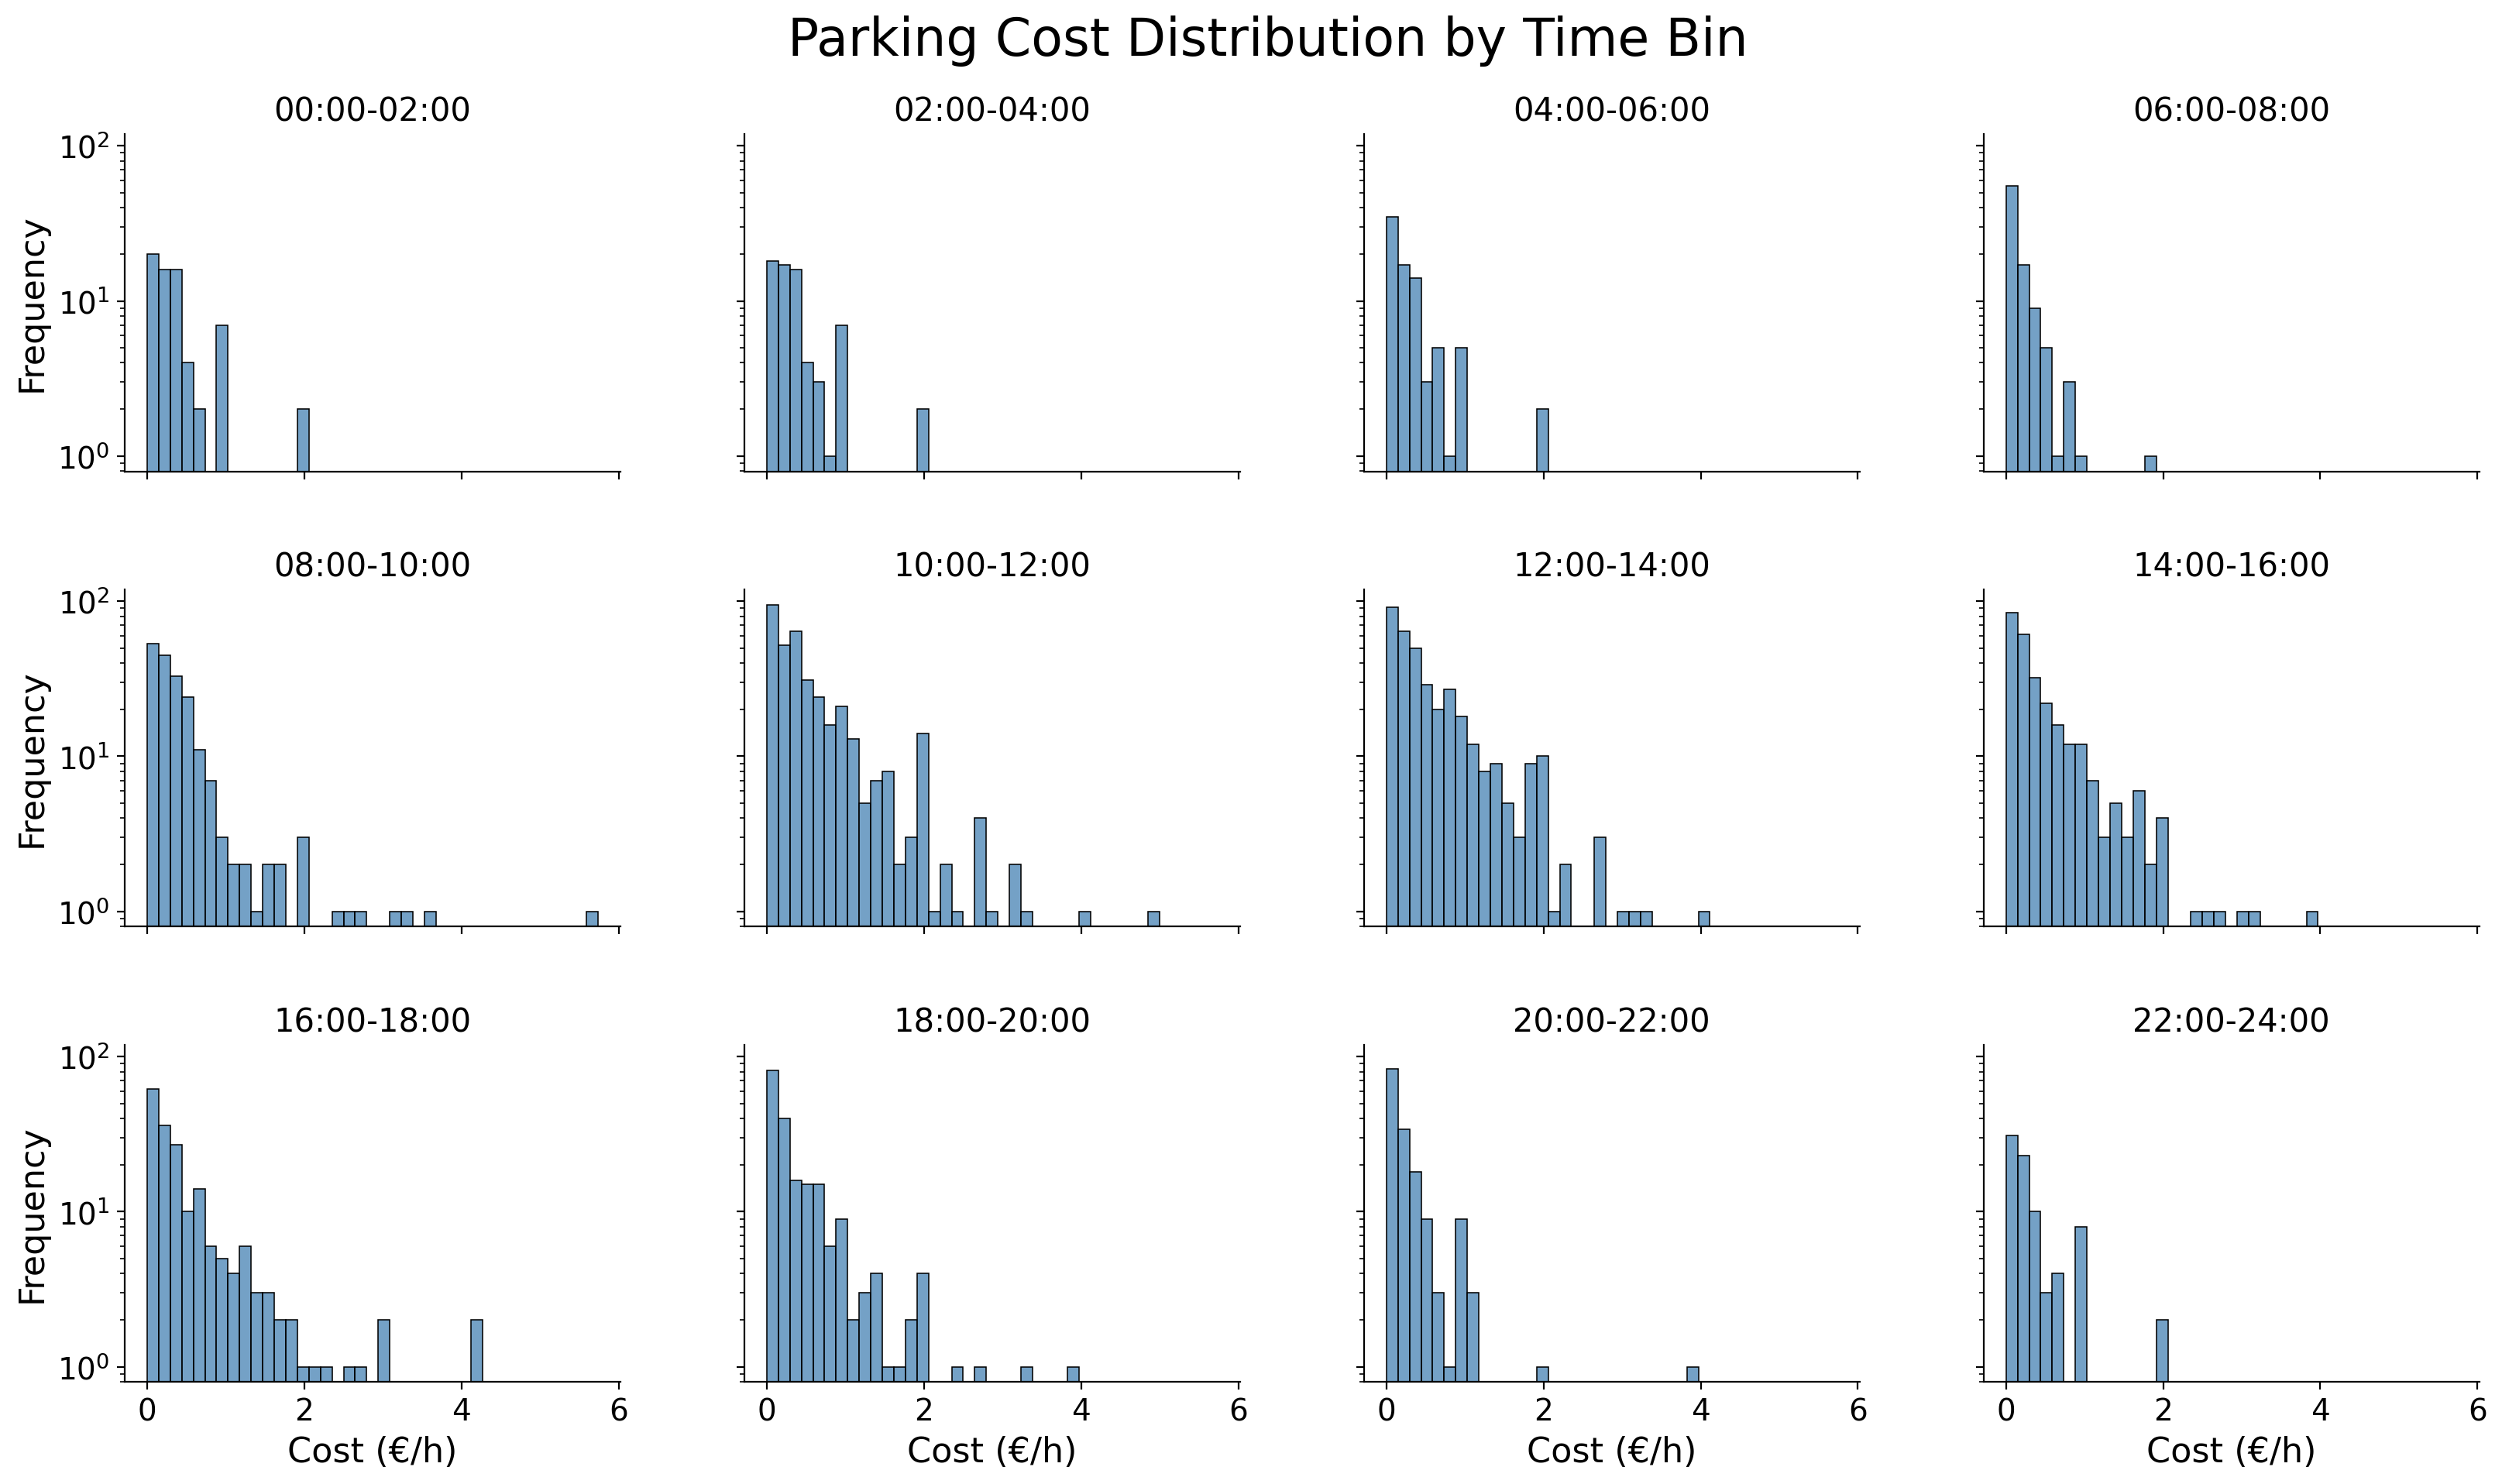

In [41]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = cost_df.copy()
df = df[df["cost"] > 0]

mapping = {
    i * 2 * 3600: f"{i*2:02d}:00-{(i+1)*2:02d}:00"
    for i in range(12)
}

order = [
    f"{i*2:02d}:00-{(i+1)*2:02d}:00"
    for i in range(12)
]

df["time_label"] = df["from_time"].map(mapping)
df["time_label"] = pd.Categorical(
    df["time_label"],
    categories=order,
    ordered=True
)

# fixed bin edges for all facets
bins = np.linspace(df["cost"].min(), df["cost"].max(), 40)

g = sns.FacetGrid(
    df,
    col="time_label",
    col_order=order,
    col_wrap=4,
    sharex=True,
    sharey=True,
    height=3.2,
    aspect=1.25
)

g.map_dataframe(
    sns.histplot,
    x="cost",
    bins=bins,
    color="steelblue",
    edgecolor="black"
)

for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlabel("Cost (€/h)", fontsize=16)
    ax.set_ylabel("Frequency", fontsize=16)
    ax.set_title(ax.get_title().replace("time_label = ", ""), fontsize=15)

g.fig.suptitle("Parking Cost Distribution by Time Bin", fontsize=24)
g.fig.subplots_adjust(top=0.9, hspace=0.35, wspace=0.25)

plt.savefig(
    "./plots/" + title + "_facet.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()